# 1. Demand and spatial analysis — Phase 2
**Member 3: Demand Forecasting + Spatial / Origin-Destination Analytics**

Purpose: validate pickup timestamps and build reproducible, memory-safe demand and OD aggregates from Member 1's official processed data. This phase stops at intermediate tables; forecasting and operational recommendations belong to later phases.

Demand means **one pickup per retained trip row**. The source is the official processed dataset, not a count of all raw records or all actual travel demand. No new cleaning or geography lookup is applied.

## 2. Imports and configuration
Run with Python, DuckDB and PyArrow installed. From the repository root, an isolated environment can be launched with:
```text
python -m uv run --no-project --with duckdb==1.5.5 --with pyarrow==25.0.1 --with jupyter jupyter notebook notebooks/03_demand_and_spatial_analysis.ipynb
```
All project paths are relative. The setup supports a kernel started from the repository root or `notebooks/`. The Member 3 helper contains the SQL transformations. DuckDB scans only the required columns, with a 1 GB engine memory limit, two threads and disk spill under the ignored processed-data directory. This engine limit is not a cap on total Python process memory. No source-sized pandas objects are constructed.

In [1]:
from pathlib import Path
import os
import sys
import importlib
import json
import duckdb
import pyarrow

if not Path("data/processed/clean_trips.parquet").is_file():
    if Path("../data/processed/clean_trips.parquet").is_file():
        os.chdir("..")
    else:
        raise FileNotFoundError("Run from the repository root or notebooks directory")
if "." not in sys.path:
    sys.path.insert(0, ".")
from src import member3_phase2 as phase2
importlib.reload(phase2)
if "con" in globals():
    con.close()
con = phase2.connect()
protected = [Path("data/processed/clean_trips.parquet"), *Path("data/splits").glob("*.parquet"),
             Path("notebooks/01_data_audit_and_cleaning.ipynb"), Path("data/feature_contract.md"),
             Path("docs/MEMBER1_HANDOVER.md"), Path("reports/data_cleaning_decisions.md")]
source_stats = {p: (p.stat().st_size, p.stat().st_mtime_ns) for p in protected}
print(f"DuckDB {duckdb.__version__}; PyArrow {pyarrow.__version__}")

DuckDB 1.5.5; PyArrow 25.0.1


## 3. Member 1 handover verification summary
Phase 1 confirmed **45,533,334 rows, 45 columns and 247 row groups**. Exact readable labels are `pickup_zone_name`, `dropoff_zone_name`, `pickup_borough_name` and `dropoff_borough_name`. `pickup_timestamp` is stored as `large_string`.

References: `data/feature_contract.md`, `docs/MEMBER1_HANDOVER.md`, `reports/data_cleaning_decisions.md`. The cleaning report describes the earlier Step 6 proposal; the handover records completion through Step 9. This notebook uses the handed-over dataset as instructed and retains its selection limitations.

The official chronological boundaries are train before 2025-12-11, validation from 2025-12-11 to before 2026-02-05, and test from 2026-02-05. This descriptive phase does not read or change those splits.

In [2]:
phase2.verify()

Handover verified: 45,533,334 rows, 45 columns, 247 row groups.


## 4. Timestamp parsing validation
An initial eight-row sample showed `YYYY-MM-DD HH:MM:SS`. Parse with `try_strptime(..., '%Y-%m-%d %H:%M:%S')` into a separate `pickup_ts` SQL view column; the original string is preserved. Count nulls and non-null parse failures separately across **every row**, report their combined percentage and timestamp bounds, and stop on any failure without dropping records.

The source sample is not physically sorted. Valid parsed timestamps permit chronological ordering; hourly exports explicitly sort by parsed hour. Timestamps remain timezone-naive as supplied: no timezone or daylight-saving correction is inferred.

In [3]:
timestamps = phase2.validate_timestamps(con)

Timestamp sample: ['2025-04-01 00:47:06', '2025-04-01 00:27:35', '2025-04-01 00:24:07', '2025-04-01 00:56:30', '2025-04-01 00:00:17', '2025-04-01 00:54:37', '2025-04-01 00:11:13', '2025-04-01 00:33:16']


{
  "total_rows": 45533334,
  "null_timestamps": 0,
  "unparseable_timestamps": 0,
  "invalid_timestamps": 0,
  "min_pickup_timestamp": "2025-04-01 00:00:00",
  "max_pickup_timestamp": "2026-03-31 23:59:59",
  "invalid_timestamp_percent": 0.0
}
All pickup timestamps parse; chronological ordering is possible with ORDER BY pickup_ts. Physical source order is not assumed.


## 5. Data coverage summary
Unique counts exclude SQL nulls; null counts are reported separately. Readable labels, including existing special labels, are used exactly as supplied. All null geography groups remain in full aggregates; no names are invented or filled.

In [4]:
summary = phase2.coverage(con, timestamps)

{
  "total_rows": 45533334,
  "null_timestamps": 0,
  "unparseable_timestamps": 0,
  "invalid_timestamps": 0,
  "min_pickup_timestamp": "2025-04-01 00:00:00",
  "max_pickup_timestamp": "2026-03-31 23:59:59",
  "invalid_timestamp_percent": 0.0,
  "unique_pickup_zones": 260,
  "unique_pickup_boroughs": 7,
  "null_pickup_zone_name": 68352,
  "null_pickup_borough_name": 20707,
  "null_dropoff_zone_name": 82030,
  "null_dropoff_borough_name": 211432
}


## 6. Memory-safe hourly demand aggregation
Group by parsed pickup hour, pickup zone and pickup borough and count retained trips. The derived `pickup_hour` is an hourly timestamp in this analysis table; it does not overwrite Member 1's integer hour-of-day field. Preserve observed groups, including null labels. Require the sum of hourly counts to equal the source row count.

In [5]:
phase2.hourly(con)

Hourly aggregate: 1,442,391 rows; 45,533,334 pickups reconciled.


## 7. Top-zone selection and compact demand EDA
Rank readable pickup zone names by total retained pickups across the full observed period, with name as a deterministic tie-break. Select the top 10 non-null names. Verify that each selected zone maps to one supplied borough before assigning its label.

Only these 10 zones receive the complete hourly grid from the minimum to maximum observed hour, inclusive. Fill zero **only when no aggregate row exists**, and retain a `filled_zero` indicator. Assumption: the source covers this period, so an absent zone-hour means zero recorded retained pickups. This does not establish zero actual demand or rule out missing source coverage. Timezone-naive clock changes are not corrected; a nonexistent local clock hour may consequently be represented by zero. First/last hours can be partial at the observed boundaries. Report global absent hours so the assumption is visible.

The ranking is descriptive and uses the full period as requested. Later honest forecasting evaluation must select zones using training data or explicitly treat these zones as a fixed retrospective cohort; this full-period ranking must not be presented as training-only selection.

Prepare total pickups by hour of day, ISO weekday (Monday=1), zone and borough. These are volume totals, not exposure-normalized hourly or daily averages.

In [6]:
phase2.top_zones(con)

(1, 'Upper East Side South', 2014915)
(2, 'JFK Airport', 1923134)
(3, 'Midtown Center', 1922045)
(4, 'Upper East Side North', 1770798)
(5, 'Penn Station/Madison Sq West', 1433926)
(6, 'Midtown East', 1408405)
(7, 'Times Sq/Theatre District', 1364421)
(8, 'Lincoln Square East', 1295316)
(9, 'LaGuardia Airport', 1213660)
(10, 'Murray Hill', 1202194)
Complete top-zone series: 87,600 rows; 718 absent zone-hours filled with zero.
Global hours with no records: 1


## 8. Memory-safe origin-destination aggregation
Scan the official Parquet directly for full zone-to-zone, borough-to-borough and time-bucketed OD counts. Null endpoints remain separate SQL groups, and each full table must reconcile to the source count.

Time buckets are based on pickup clock time with half-open boundaries:
- Morning peak: [06:00, 10:00)
- Midday: [10:00, 16:00)
- Evening peak: [16:00, 20:00)
- Late night: [20:00, 24:00) and [00:00, 06:00)

Buckets are mutually exclusive and cover every parsed pickup. Both zone and borough OD tables are produced by bucket.

In [7]:
phase2.od(con)

od_zone: 55,182 aggregate rows; 45,533,334 trips reconciled.
od_borough: 64 aggregate rows; 45,533,334 trips reconciled.
od_zone_time: 183,686 aggregate rows; 45,533,334 trips reconciled.
od_borough_time: 251 aggregate rows; 45,533,334 trips reconciled.


## 9. Save intermediate aggregated tables
Full hourly and OD Parquet tables use Zstandard compression under `data/processed/member3_*.parquet`. Existing `.gitignore` rules exclude them; do not force-add these outputs. Re-running replaces only these Member 3 outputs.

Small CSV reports contain the top-10 ranking, all zone/borough demand totals, hour/weekday totals, top 100 overall zone OD pairs, all borough OD pairs, all bucketed borough pairs, and top 25 zone OD pairs per bucket. **Zone OD CSVs are explicitly truncated summaries**; the corresponding Parquet files contain every pair. Empty CSV fields represent SQL nulls; Parquet preserves null types. Full-aggregate reconciliation does not apply to truncated reports.

The JSON summary records coverage, zero-fill count and each table's row count and exact byte size.

In [8]:
outputs = phase2.save(con, summary)

Global hours without source records: ['2026-03-08 02:00:00']
data/processed/member3_hourly_demand.parquet: 1,442,391 rows; 2,404,708 bytes
data/processed/member3_top_zone_hourly.parquet: 87,600 rows; 182,251 bytes
data/processed/member3_od_zone_pairs.parquet: 55,182 rows; 140,882 bytes
data/processed/member3_od_borough_pairs.parquet: 64 rows; 1,186 bytes
data/processed/member3_od_zone_time.parquet: 183,686 rows; 393,098 bytes
data/processed/member3_od_borough_time.parquet: 251 rows; 1,904 bytes
reports/member3_top_zones.csv: 10 rows; 336 bytes
reports/member3_demand_by_hour.csv: 24 rows; 298 bytes
reports/member3_demand_by_weekday.csv: 7 rows; 168 bytes
reports/member3_pickup_zone_totals.csv: 261 rows; 6,124 bytes
reports/member3_pickup_borough_totals.csv: 8 rows; 155 bytes
reports/member3_od_zone_pairs.csv: 100 rows; 4,435 bytes
reports/member3_od_borough_pairs.csv: 64 rows; 1,378 bytes
reports/member3_od_borough_time.csv: 251 rows; 7,841 bytes
reports/member3_od_zone_time_top.csv: 10

## 10. Phase 2 summary
The cell below confirms completion only after timestamp, count and complete-index checks pass. Member 1 file sizes and modification times are compared with the setup snapshot. This is an unchanged-file check, not a cryptographic content audit.

Review the recorded coverage and output inventory above before later modelling. Forecasting, final charts and final operational recommendations have not started.

In [9]:
assert all((p.stat().st_size, p.stat().st_mtime_ns) == before for p, before in source_stats.items()), "STOP: Member 1 file metadata changed"
saved_grid = con.execute("SELECT pickup_hour, pickup_zone_name, pickup_count, filled_zero FROM read_parquet('data/processed/member3_top_zone_hourly.parquet')").fetchall()
assert [(r[0], r[1]) for r in saved_grid] == sorted((r[0], r[1]) for r in saved_grid), "STOP: saved grid is not chronological"
assert len({(r[0], r[1]) for r in saved_grid}) == len(saved_grid), "STOP: duplicate zone-hours"
assert all(r[2] >= 0 and (not r[3] or r[2] == 0) for r in saved_grid), "STOP: invalid saved counts"
del saved_grid  # This check reads only the compact 87,600-row grid.
print(f"Phase 2 complete: {summary['total_rows']:,} retained pickups; {summary['invalid_timestamps']} invalid timestamps.")
print(f"Coverage: {summary['min_pickup_timestamp']} through {summary['max_pickup_timestamp']}.")
print(f"Saved {len(outputs)} aggregate tables; Member 1 file sizes and modification times unchanged.")
con.close()

Phase 2 complete: 45,533,334 retained pickups; 0 invalid timestamps.
Coverage: 2025-04-01 00:00:00 through 2026-03-31 23:59:59.
Saved 15 aggregate tables; Member 1 file sizes and modification times unchanged.


# 11. Phase 3 — Demand forecasting
Use only the committed 87,600-row top-zone hourly table. Demand is retained pickup count, with the existing 718 zero-filled zone-hours unchanged. The ten zones were selected retrospectively from the full period in Phase 2; evaluation is **conditional on this fixed cohort**, not an unbiased evaluation of zone selection.

Phase 3 can run independently from this section without rerunning Phase 2 aggregation. Python dependencies: pandas, NumPy, scikit-learn, PyArrow and matplotlib. The execution below records installed versions. No full trip dataset is loaded.
```text
python -m uv run --no-project --with pandas==3.0.5 --with numpy==2.5.3 --with scikit-learn==1.9.0 --with matplotlib==3.11.1 --with pyarrow==25.0.1 --with jupyter jupyter notebook notebooks/03_demand_and_spatial_analysis.ipynb
```

In [1]:
from pathlib import Path
import os
import sys
import importlib
import pandas as pd
import numpy as np
import sklearn
import matplotlib
from IPython.display import display, Image
if not Path('data/processed/member3_top_zone_hourly.parquet').is_file():
    if Path('../data/processed/member3_top_zone_hourly.parquet').is_file():
        os.chdir('..')
    else:
        raise FileNotFoundError('Phase 2 aggregate not found')
if '.' not in sys.path:
    sys.path.insert(0, '.')
from src import member3_forecasting as forecasting
importlib.reload(forecasting)
protected_paths = [Path('data/processed/clean_trips.parquet'), *Path('data/splits').glob('*.parquet'),
    *Path('data/processed').glob('member3_*.parquet'), *Path('reports').glob('member3_*.csv'),
    Path('data/feature_contract.md'), Path('docs/MEMBER1_HANDOVER.md'),
    Path('reports/data_cleaning_decisions.md'), Path('notebooks/01_data_audit_and_cleaning.ipynb')]
# Phase 3 outputs may already exist on rerun; only preserve Member 1 and Phase 2 artifacts here.
protected_paths = [p for p in protected_paths if 'forecast' not in p.name]
before_stats = {p: (p.stat().st_size, p.stat().st_mtime_ns) for p in protected_paths}
print('Versions:', {'pandas': pd.__version__, 'numpy': np.__version__, 'sklearn': sklearn.__version__, 'matplotlib': matplotlib.__version__})
wide = forecasting.load_data()

Versions: {'pandas': '3.0.5', 'numpy': '2.5.3', 'sklearn': '1.9.0', 'matplotlib': '3.11.1'}


Validated compact input: 87,600 rows, 10 zones, 8,760 consecutive hours.


## 12. Seasonal baseline and lag-feature model
**Baseline:** mean historical pickups for the same zone, weekday (Monday=0) and clock hour. Fit on observations strictly before the relevant fitting cutoff; all 168 weekday/hour groups must exist. Means remain fixed throughout each evaluation split.

**Improved candidate:** one HistGradientBoostingRegressor shared by all ten zones. Features are lag 1/24/48/168, trailing 3/24-hour means shifted by one hour, hour, weekday, weekend indicator and an explicitly categorical zone code. The first 168 hours of each zone are unavailable for model fitting; this is lag warm-up, not source cleaning.

Parameters fixed before evaluation: 120 iterations, learning rate 0.08, 15 leaves, minimum 30 samples per leaf, L2=1, seed 2026. Early stopping is disabled to avoid an automatic random validation split. Two computation threads limit overhead. Negative forecasts are clipped to zero; fractional expected counts are retained.

**Multi-step rule:** for each origin, the recursive function receives only observations before that origin. It predicts all zones one hour at a time and appends its own predictions. Any lag or rolling window crossing the origin uses those predictions, never future observed targets. Actual demand revealed before later origins may be used as fresh lag history. Model parameters do not update inside the validation/test split.

## 13. Chronological validation and test evaluation
- Train: 2025-04-01 through 2025-12-10; evaluate validation from 2025-12-11 through 2026-02-04.
- Refit the same configuration on train + validation; evaluate test from 2026-02-05 through 2026-03-31.
- Daily midnight origins are eligible only when their entire 72-hour path lies within the split: 54 validation origins and 53 test origins. Use these same origins for all horizons.
- A horizon score pools the **first H hourly predictions**, not only the Hth lead, equally over every origin and zone. The 48/72-hour windows overlap; repeated target hours represent different forecast origins. These scores are not independent-sample uncertainty estimates. Shorter horizons consequently end earlier than the full split boundary.
- Report MAE and RMSE in pickups per zone-hour. Winner is determined by MAE. The candidate configuration is not tuned on test results.

Primary scores retain the documented zero at 2026-03-08 02:00, consistent with Phase 2. A separate sensitivity CSV excludes only target predictions for that globally absent hour; it does not alter source data, training or lag history. No timezone correction is inferred.

In [2]:
feature_data, backtests, metrics, evaluation_seconds = forecasting.evaluate(wide)
display(metrics)

Fit through 2025-12-10 23:00:00: 59,280 lag-feature rows.


validation: 54 daily origins, 2025-12-11 00:00:00 through 2026-02-02 00:00:00.
     split  horizon_hours  n_predictions  n_origins  baseline_mae  baseline_rmse  improved_mae  improved_rmse   winner
validation             24          12960         54  46.578288242   72.651023923  37.619227263   59.089615377 Improved
validation             48          25920         54  46.332168395   72.258484769  41.017246156   64.229846803 Improved
validation             72          38880         54  46.081913820   71.926199672  42.966829933   67.256696682 Improved


Fit through 2026-02-04 23:00:00: 72,720 lag-feature rows.


test: 53 daily origins, 2026-02-05 00:00:00 through 2026-03-29 00:00:00.
split  horizon_hours  n_predictions  n_origins  baseline_mae  baseline_rmse  improved_mae  improved_rmse   winner
 test             24          12720         53  33.603788911   53.826564740  32.302992781   52.090000550 Improved
 test             48          25440         53  33.574418557   53.772857929  34.268282886   55.024541569 Baseline
 test             72          38160         53  33.571390821   53.751538591  35.188656381   56.369612289 Baseline


,split,horizon_hours,n_predictions,n_origins,baseline_mae,baseline_rmse,improved_mae,improved_rmse,winner
0,validation,24,12960,54,46.578288,72.651024,37.619227,59.089615,Improved
1,validation,48,25920,54,46.332168,72.258485,41.017246,64.229847,Improved
2,validation,72,38880,54,46.081914,71.926200,42.966830,67.256697,Improved
3,test,24,12720,53,33.603789,53.826565,32.302993,52.090001,Improved
4,test,48,25440,53,33.574419,53.772858,34.268283,55.024542,Baseline
5,test,72,38160,53,33.571391,53.751539,35.188656,56.369612,Baseline


## 14. Save forecasts and visualize held-out demand
The diagnostic chart shows the **last eligible test origin**, chosen by date, summing the ten zones. It is an illustrative path; reported scores remain per-zone and use all origins.

After evaluation, refit both methods on all observed data and forecast 2026-04-01 00:00 through 2026-04-03 23:00. `reports/forecast_24h.csv`, `forecast_48h.csv` and `forecast_72h.csv` contain both forecasts, origin, target hour, zone and lead. These future predictions have no observed targets and are not the source of reported test scores. The shorter files are prefixes of the same 72-hour forecast.

Full validation/test predictions are saved to ignored `data/processed/member3_forecast_backtest.parquet` for audit. Metrics, sensitivity results and run summary are small reports; no model binary is saved.

Fit through 2026-03-31 23:00:00: 85,920 lag-feature rows.
[
  {
    "path": "reports/forecast_24h.csv",
    "rows": 240,
    "bytes": 21627
  },
  {
    "path": "reports/forecast_48h.csv",
    "rows": 480,
    "bytes": 43286
  },
  {
    "path": "reports/forecast_72h.csv",
    "rows": 720,
    "bytes": 64921
  }
]
Evaluation runtime: 15.7 seconds. Future forecasts start 2026-04-01 00:00:00.


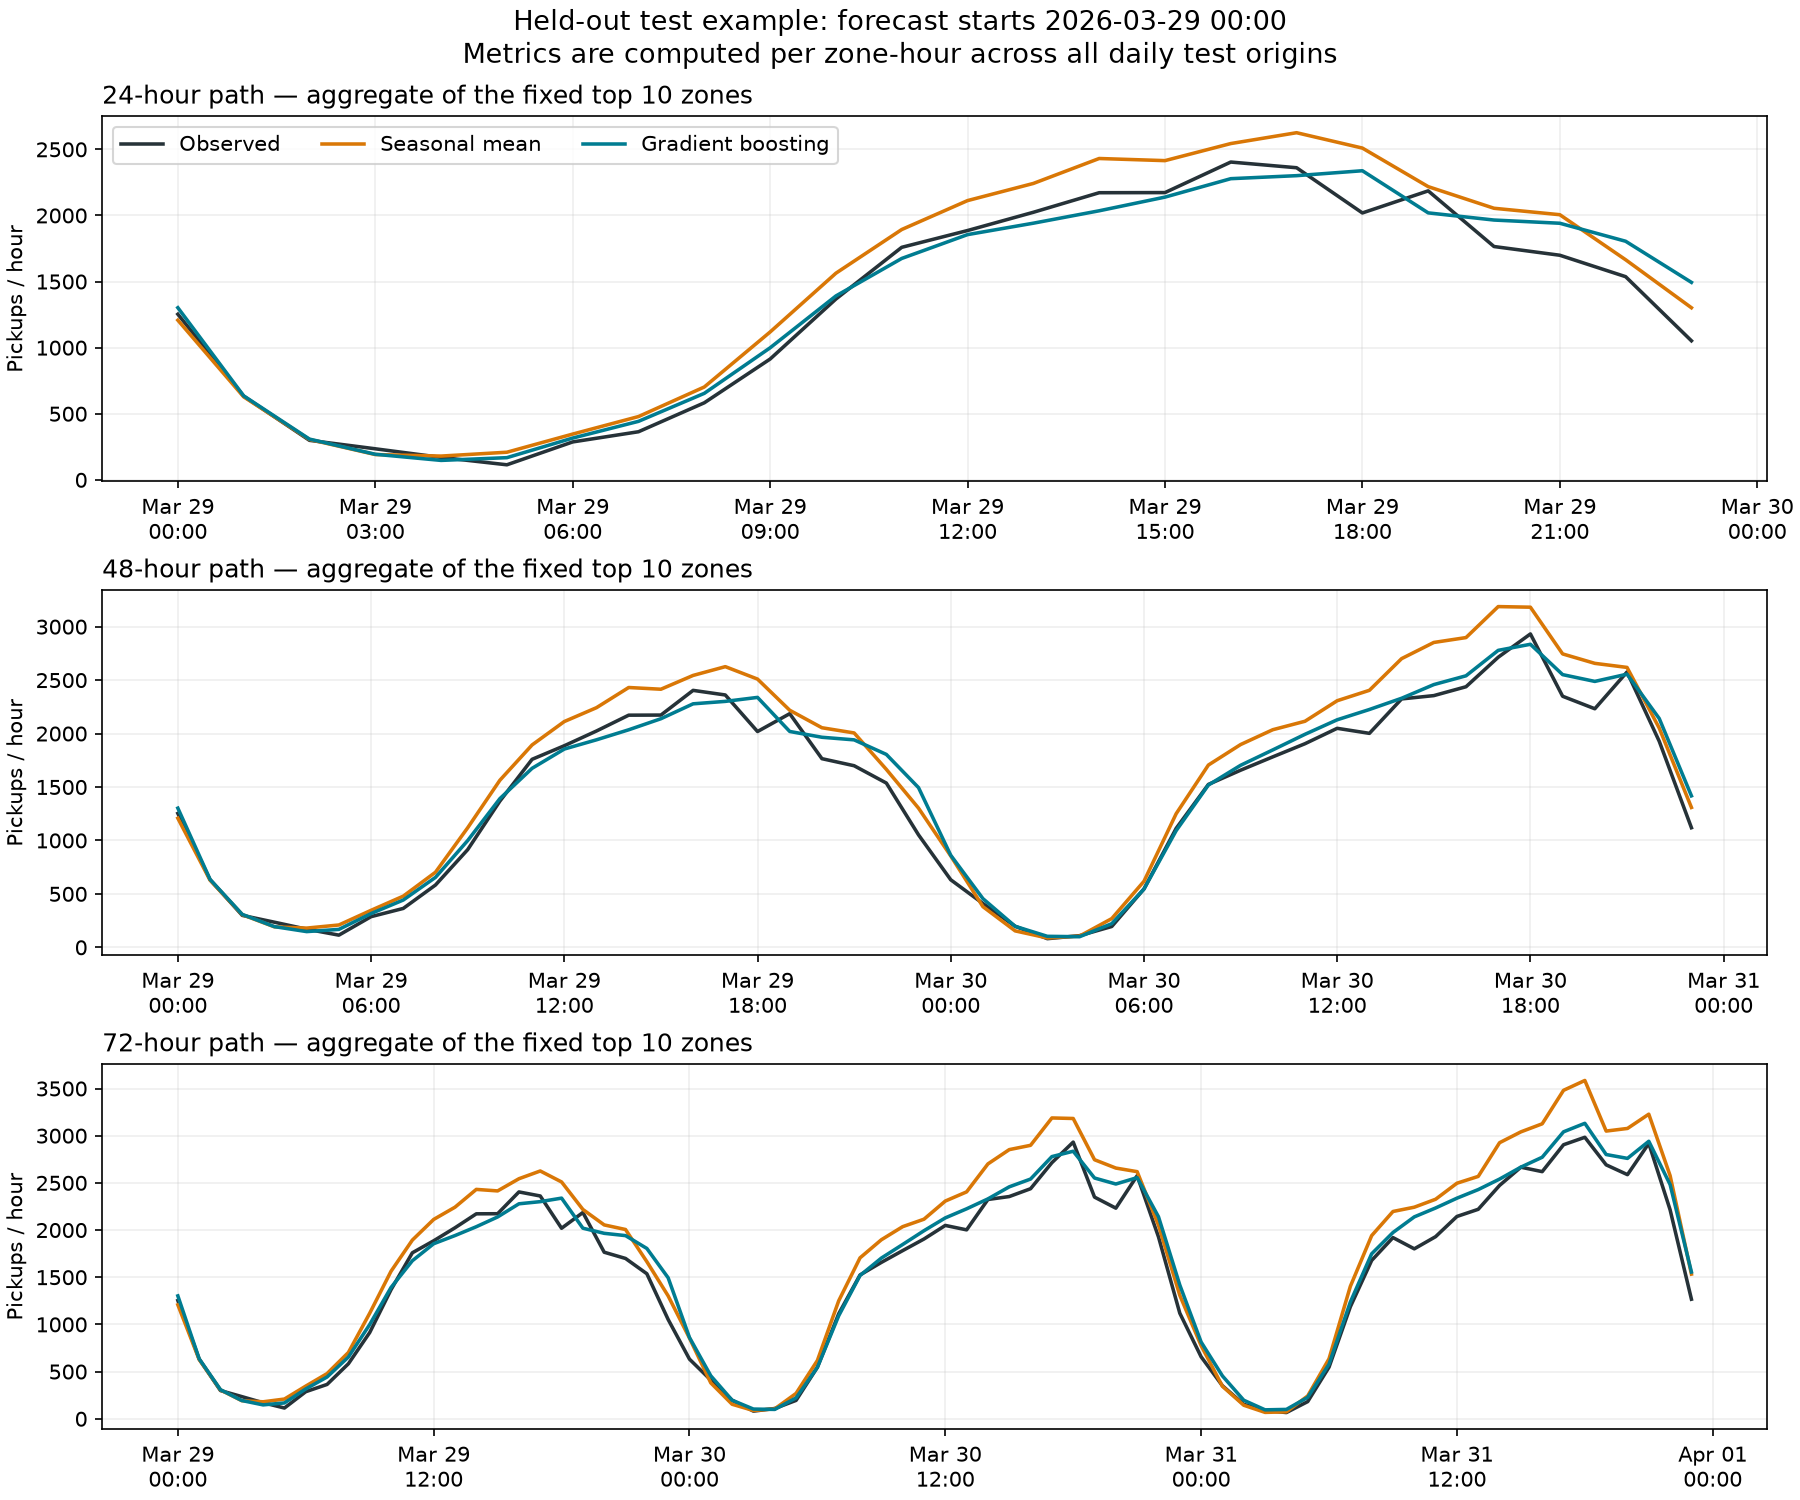

In [3]:
forecast_summary = forecasting.save_outputs(wide, feature_data, backtests, metrics, evaluation_seconds)
display(Image(filename='reports/figures/demand_forecast.png'))

## 15. Comparison and short interpretation
The printed table below uses held-out test data. Improvements describe this fixed retrospective cohort and the selected daily-origin protocol. No operational recommendations are made in this phase.

In [4]:
test_metrics = metrics.loc[metrics.split.eq('test')].copy()
comparison = test_metrics[['horizon_hours', 'baseline_mae', 'improved_mae', 'winner']]
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.9f}'))
for row in test_metrics.itertuples():
    change = 100 * (row.baseline_mae - row.improved_mae) / row.baseline_mae
    print(f'{row.horizon_hours}h: {row.winner} wins by MAE; candidate MAE reduction {change:.2f}%. '
          f'Baseline RMSE {row.baseline_rmse:.9f}; candidate RMSE {row.improved_rmse:.9f}.')
assert all((p.stat().st_size, p.stat().st_mtime_ns) == old for p, old in before_stats.items()), 'STOP: protected input file changed'
print('Phase 3 complete. Member 1 and Phase 2 input sizes and modification times unchanged.')

 horizon_hours  baseline_mae  improved_mae   winner
            24  33.603788911  32.302992781 Improved
            48  33.574418557  34.268282886 Baseline
            72  33.571390821  35.188656381 Baseline
24h: Improved wins by MAE; candidate MAE reduction 3.87%. Baseline RMSE 53.826564740; candidate RMSE 52.090000550.
48h: Baseline wins by MAE; candidate MAE reduction -2.07%. Baseline RMSE 53.772857929; candidate RMSE 55.024541569.
72h: Baseline wins by MAE; candidate MAE reduction -4.82%. Baseline RMSE 53.751538591; candidate RMSE 56.369612289.
Phase 3 complete. Member 1 and Phase 2 input sizes and modification times unchanged.


# 16. Phase 4 — Spatial patterns and operational interpretation
This section can run independently from here. Reuse full Phase 2 demand and OD aggregates, not the truncated top-pair CSVs. The only direct source scan creates the missing destination-total report, reading `dropoff_zone_name` with DuckDB. Neither source cleaning nor earlier aggregation/model fitting is repeated in Phase 4.

Dependencies: DuckDB 1.5.5, pandas 3.0.5, NumPy 2.5.3, matplotlib 3.11.1 and PyArrow 25.0.1. Add DuckDB to the isolated environment shown in Phase 3 to run this section. All project paths are relative. Earlier sections remain runnable when intentionally rebuilding the entire analysis.

In [1]:
from pathlib import Path
import os
import sys
import importlib
from IPython.display import display, Image, Markdown
if not Path('data/processed/member3_od_zone_pairs.parquet').is_file():
    if Path('../data/processed/member3_od_zone_pairs.parquet').is_file():
        os.chdir('..')
    else:
        raise FileNotFoundError('Phase 2 OD inputs not found')
if '.' not in sys.path:
    sys.path.insert(0, '.')
from src import member3_spatial as spatial
importlib.reload(spatial)
phase4_outputs = {'member3_dropoff_zone_totals.csv'}
protected = [Path('data/processed/clean_trips.parquet'), *Path('data/splits').glob('*.parquet'),
    *Path('data/processed').glob('member3_*.parquet'), *Path('reports').glob('member3_*.csv'),
    *Path('reports').glob('forecast_*.csv'), Path('reports/figures/demand_forecast.png'),
    Path('notebooks/01_data_audit_and_cleaning.ipynb'), Path('data/feature_contract.md'),
    Path('docs/MEMBER1_HANDOVER.md'), Path('reports/data_cleaning_decisions.md')]
protected = [p for p in protected if p.name not in phase4_outputs and not p.name.startswith('member3_spatial_')]
protected_stats = {p: (p.stat().st_size, p.stat().st_mtime_ns) for p in protected}
spatial_tables = spatial.read_inputs()

Existing demand and OD totals reconcile to 45,533,334 retained trips.


## 17. Pickup and destination hotspots
Retain SQL-null location groups in all total counts. Restrict top-10 displays to readable labels and do not invent coordinates, borough assignments or geography. The destination-only SQL scan returns a compact grouped table; its counts must match destination marginals from the existing full OD table, including missing labels.

Demand remains one pickup per retained trip. Destination totals count dropoffs of those same retained trips; they are not filtered by dropoff time.

In [2]:
spatial.derive_destinations(spatial_tables)
spatial.prepare(spatial_tables)
display(spatial_tables['top_pickup'])
display(spatial_tables['top_dropoff'])

Destination report: 262 groups; direct scan and full OD marginals agree exactly.
 time_bucket  trip_count  window_hours_per_day  share_percent  mean_pickups_per_nominal_hour
morning_peak     5724154                     4          12.57                       3,920.65
      midday    14045862                     6          30.85                       6,413.64
evening_peak    11883847                     4          26.10                       8,139.62
  late_night    13879471                    10          30.48                       3,802.59


,pickup_zone_name,pickup_count
0,Upper East Side South,2014915
1,JFK Airport,1923134
2,Midtown Center,1922045
3,Upper East Side North,1770798
4,Penn Station/Madison Sq West,1433926
5,Midtown East,1408405
6,Times Sq/Theatre District,1364421
7,Lincoln Square East,1295316
8,LaGuardia Airport,1213660
9,Murray Hill,1202194


,dropoff_zone_name,dropoff_count
0,Upper East Side North,1835816
1,Upper East Side South,1825726
2,Midtown Center,1591040
3,Times Sq/Theatre District,1302813
4,Murray Hill,1251418
5,Midtown East,1194074
6,East Chelsea,1149412
7,Lincoln Square East,1148423
8,Upper West Side South,1143692
9,Lenox Hill West,1096437


## 18. Directed OD flows and time-of-day comparison
Use pickup → destination direction. Same-zone trips do not imply identical physical endpoints. Full OD marginals and all time-bucket totals are reconciled before interpretation.

Buckets remain [06:00,10:00), [10:00,16:00), [16:00,20:00), and [20:00,24:00) + [00:00,06:00). Windows have different durations, so compare both annual counts and counts / (365 × nominal window hours). These are descriptive clock-hour rates, not estimated active-service-hour demand. Preserve the documented missing hour at 2026-03-08 02:00; do not infer a clock correction.

Show ten overall directed zone pairs, five per time bucket, and a borough-label matrix. The matrix retains supplied special labels and explicitly displays nulls as `(missing label)`; that marker is not a new geographic category.

In [3]:
display(spatial_tables['top_zone_pairs'])
display(spatial_tables['bucket_summary'])
display(spatial_tables['top_time_pairs'])

,pickup_zone_name,dropoff_zone_name,trip_count
0,Upper East Side South,Upper East Side North,290297
1,Upper East Side North,Upper East Side South,247748
2,Upper East Side South,Upper East Side South,202435
3,Upper East Side North,Upper East Side North,186379
4,Midtown Center,Upper East Side South,135074
5,Upper East Side South,Midtown Center,126222
6,Midtown Center,Upper East Side North,108494
7,Upper East Side South,Midtown East,101001
8,Lincoln Square East,Upper West Side South,100044
9,Upper West Side South,Upper West Side North,96591


,time_bucket,trip_count,window_hours_per_day,share_percent,mean_pickups_per_nominal_hour
0,morning_peak,5724154,4,12.571348,3920.653425
1,midday,14045862,6,30.847427,6413.635616
2,evening_peak,11883847,4,26.099224,8139.621233
3,late_night,13879471,10,30.482000,3802.594795


,time_bucket,pickup_zone_name,dropoff_zone_name,trip_count
0,morning_peak,Upper East Side North,Midtown Center,35293
1,morning_peak,Upper East Side North,Upper East Side South,34622
2,morning_peak,Upper East Side South,Upper East Side North,33437
3,morning_peak,Upper East Side North,Upper East Side North,26818
4,morning_peak,Upper East Side South,Midtown Center,25882
5,midday,Upper East Side South,Upper East Side North,126637
6,midday,Upper East Side North,Upper East Side South,120366
7,midday,Upper East Side South,Upper East Side South,91859
8,midday,Upper East Side North,Upper East Side North,85890
9,midday,Upper East Side South,Midtown Center,57558


## 19. Final spatial and demand visuals
Hotspots show pickups and destinations side-by-side. Hour-of-day demand is normalized by 365 calendar days. OD charts filter to readable top-N pairs; the borough matrix includes all label groups and annotates exact counts. Time-window panels use total trips, while normalized rates are provided in the comparison table above.

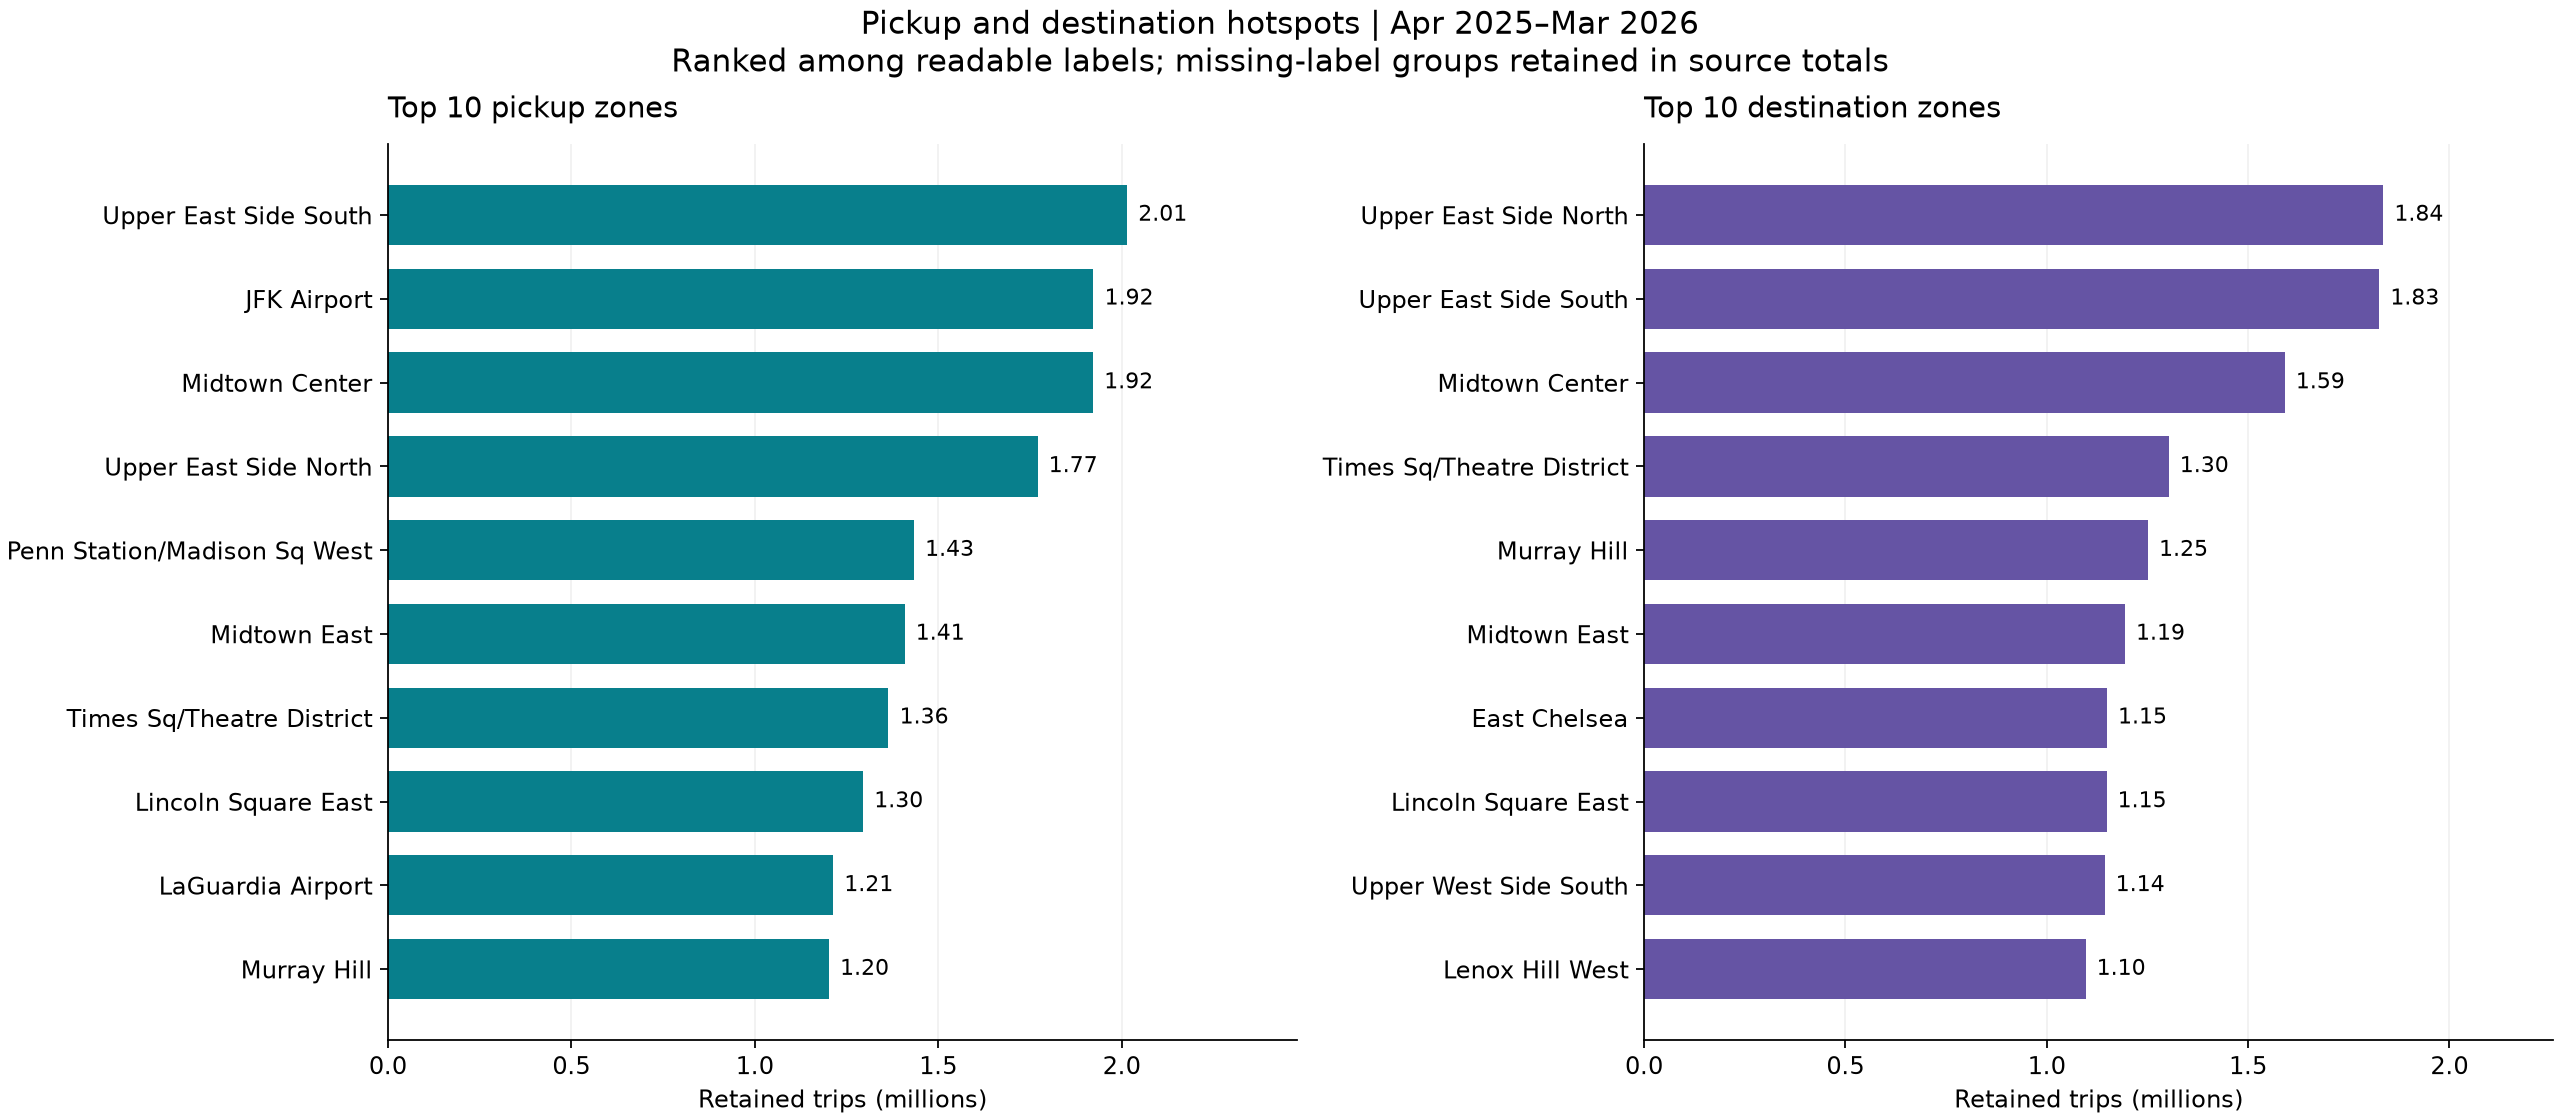

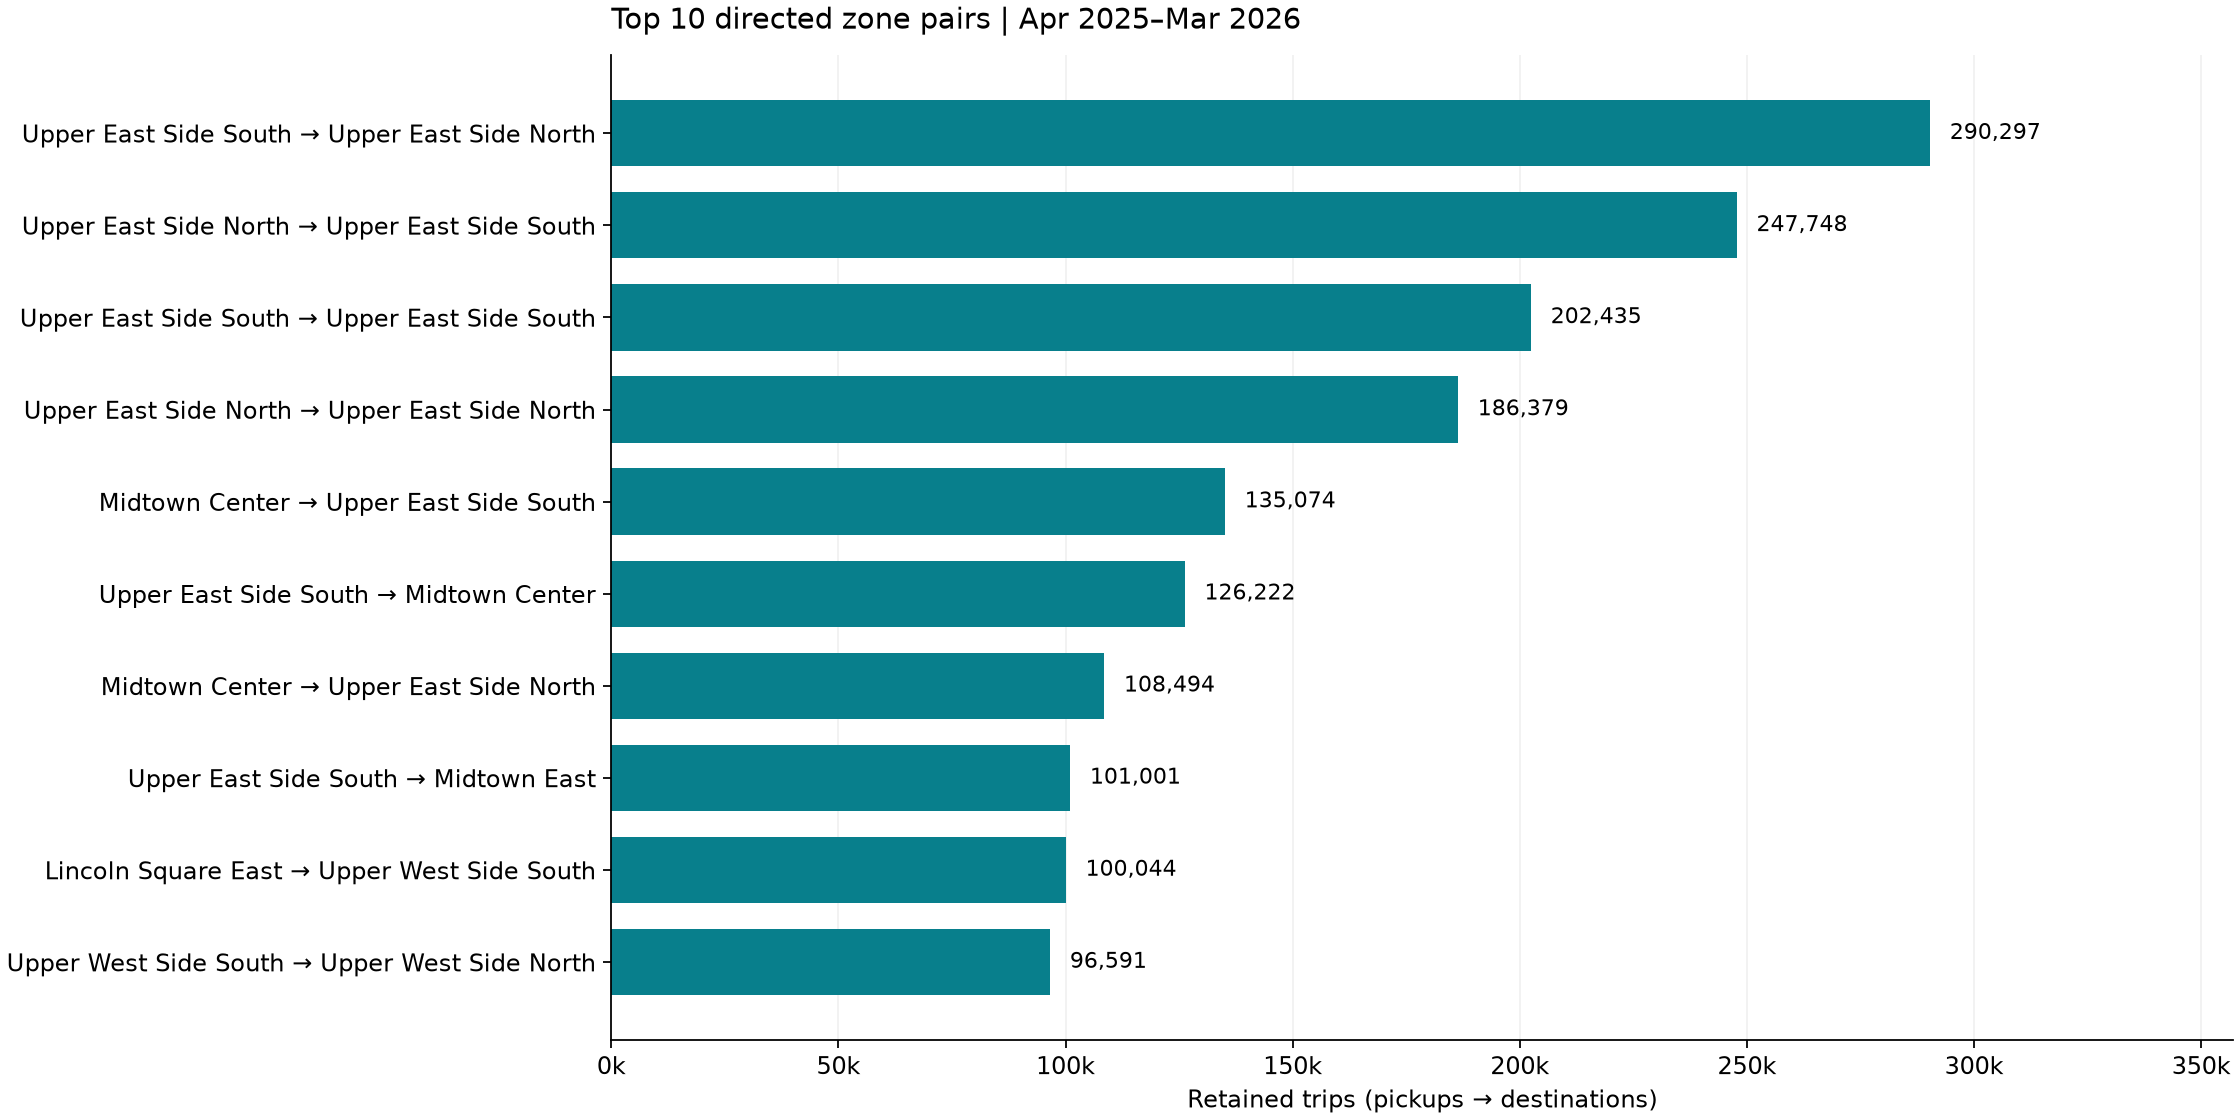

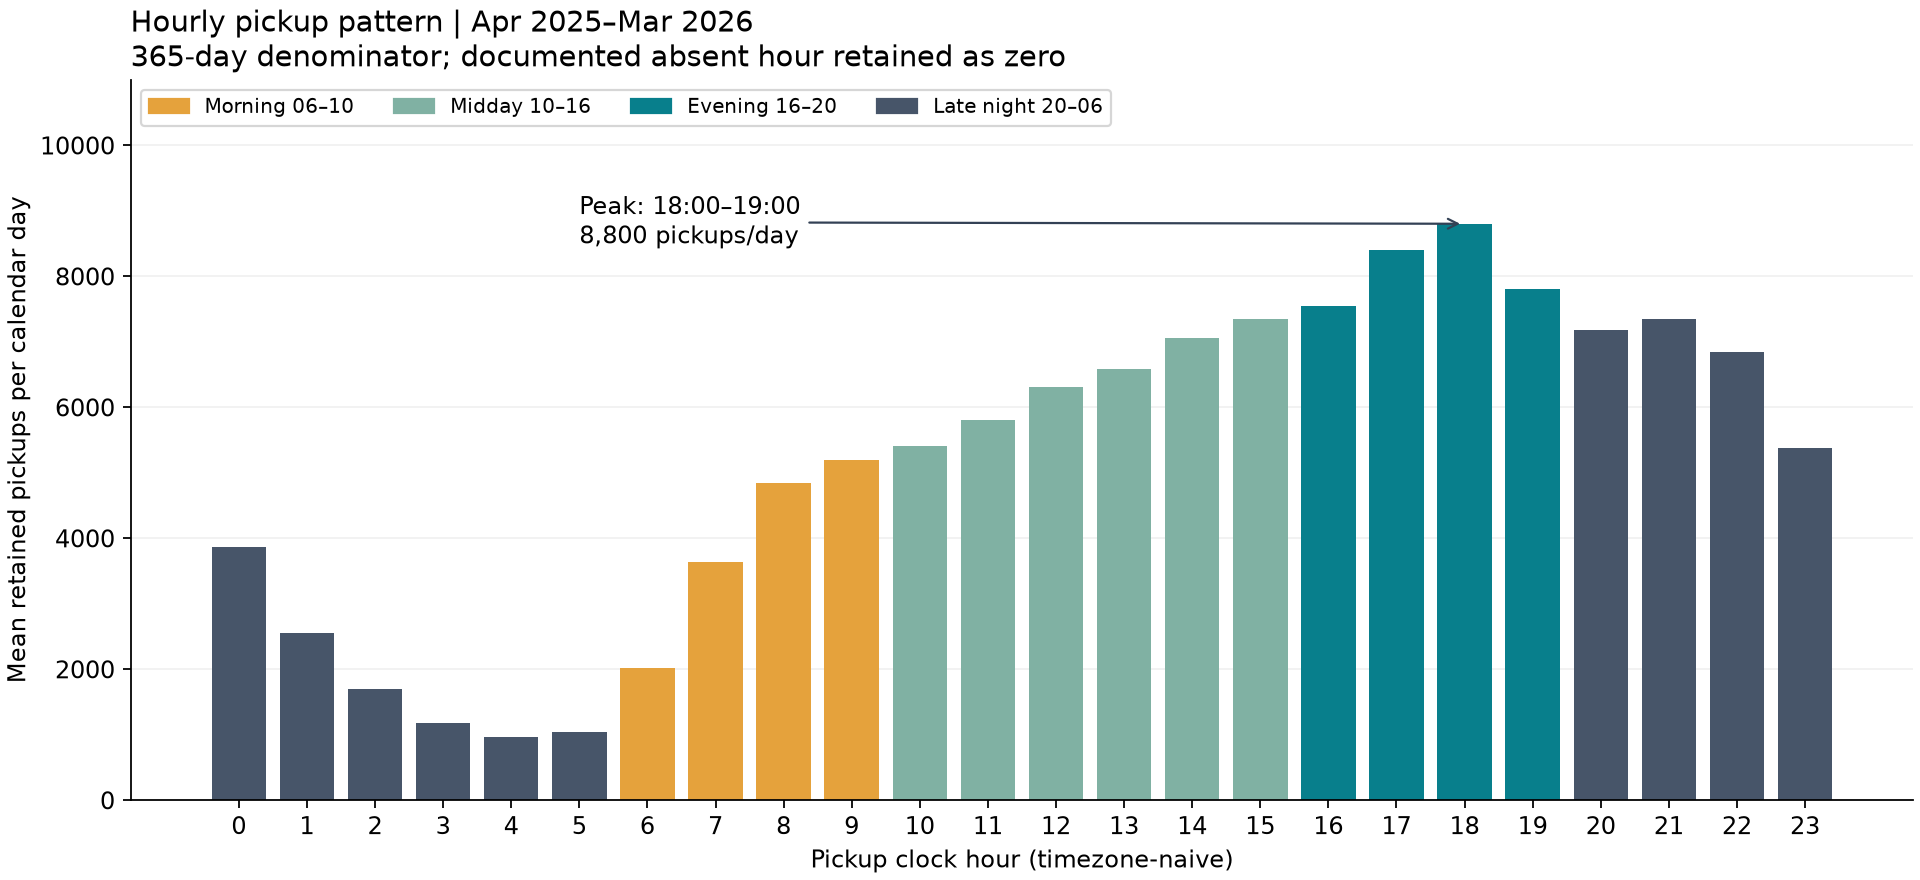

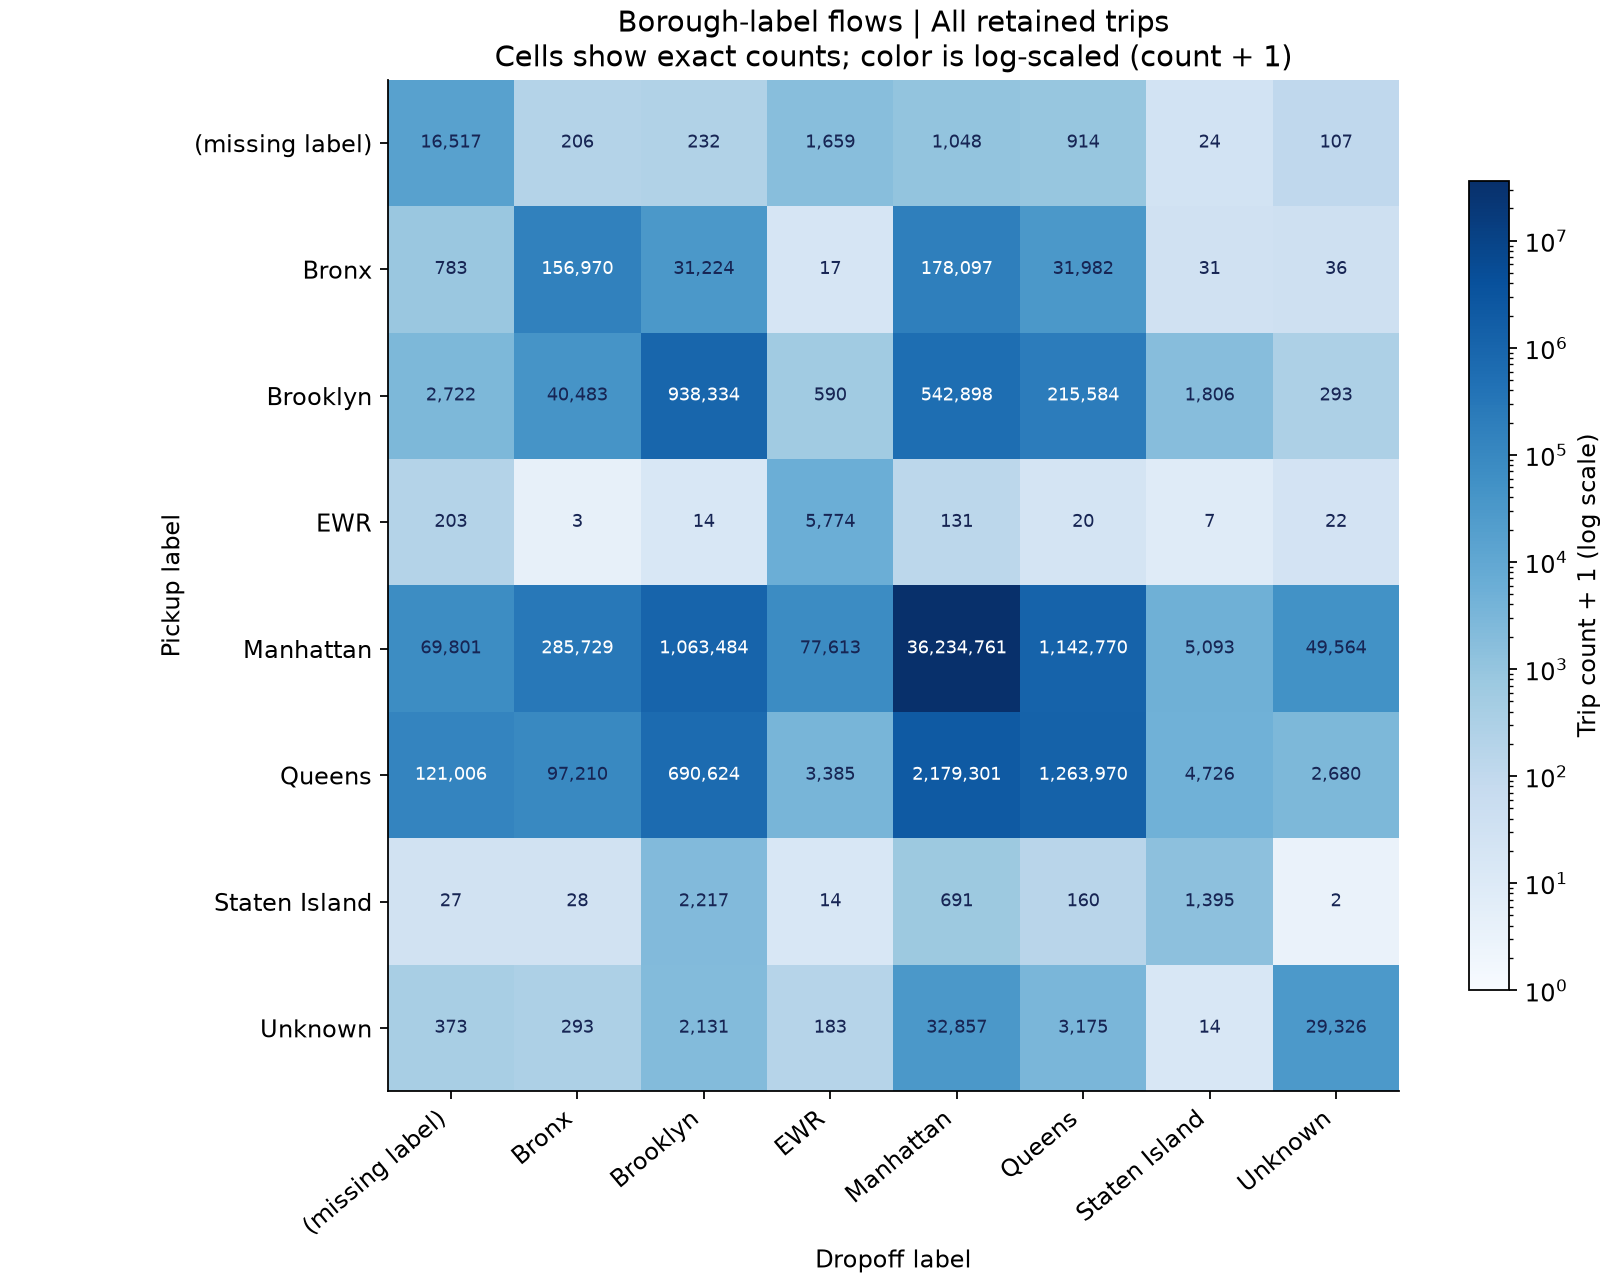

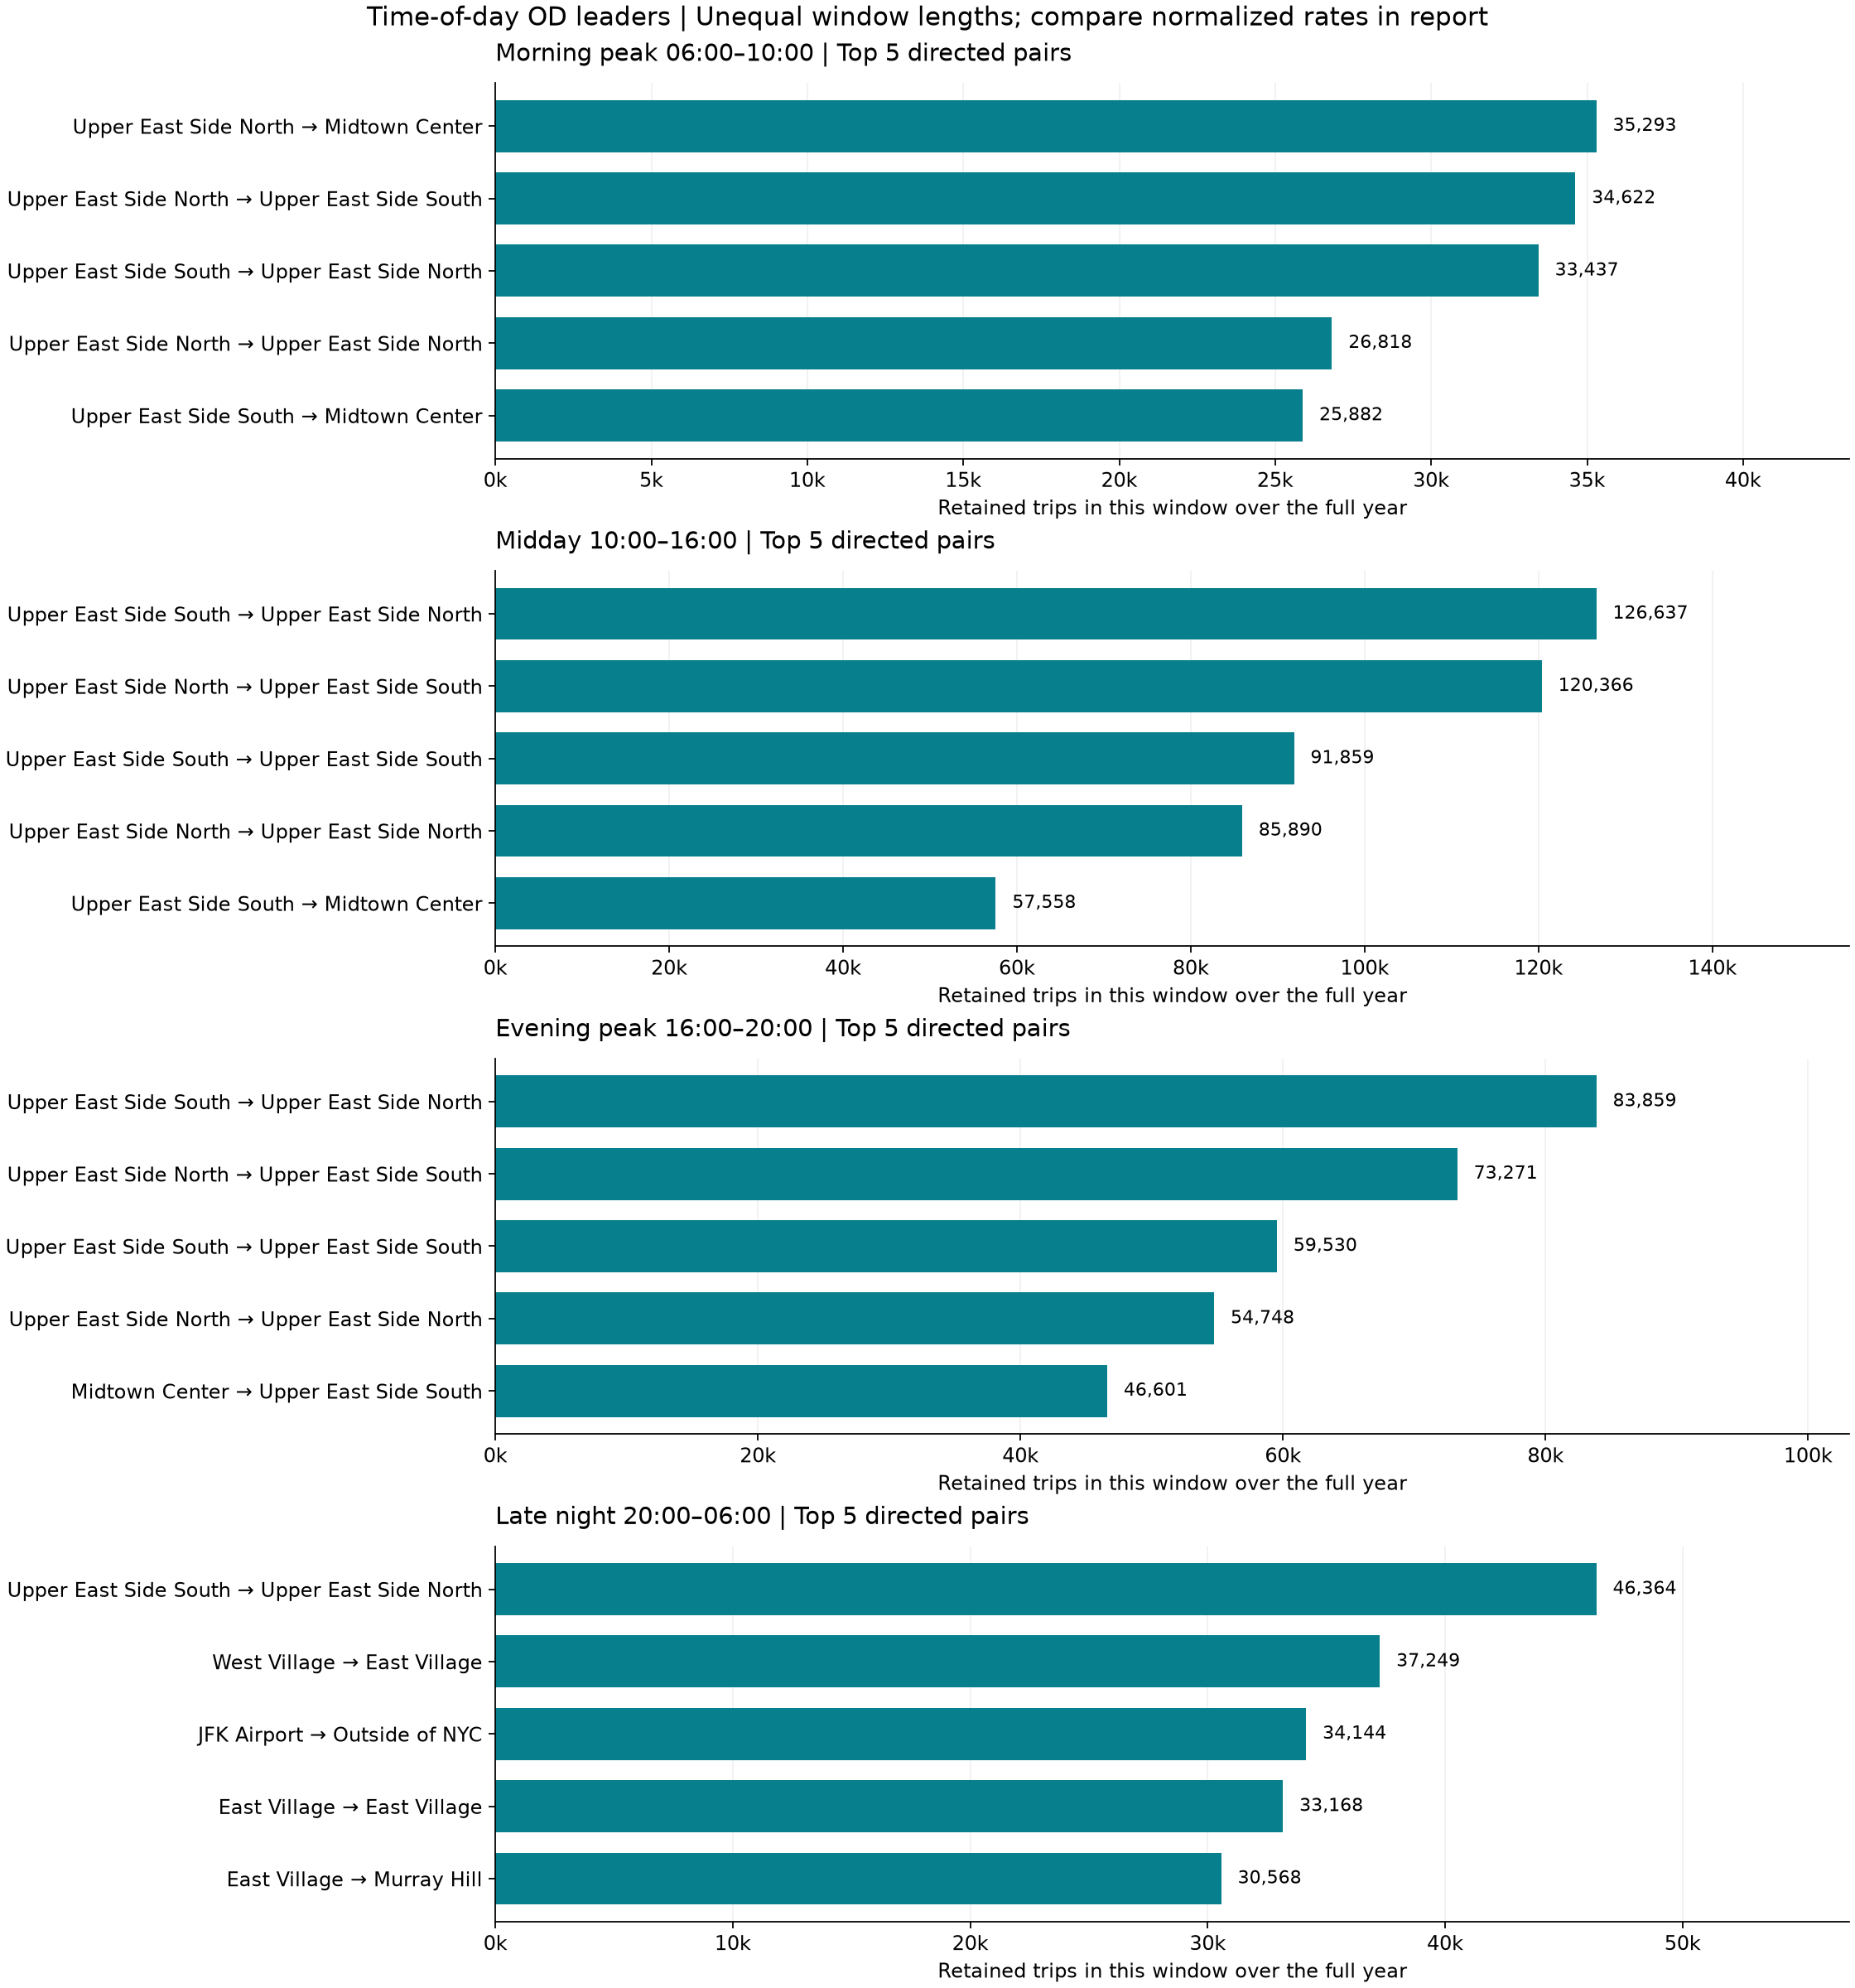

In [4]:
spatial.draw(spatial_tables)
for filename in ['hotspot_zones.png','od_flows.png','demand_by_hour.png','member3_borough_flows.png','member3_od_by_time.png']:
    display(Image(filename='reports/figures/'+filename))

## 20. Final findings and operational recommendations
The report below is generated from the reconciled tables and existing Phase 3 metrics. Each numeric finding links to a supporting table or chart. Recommendations identify possible operational actions without claiming proven capacity shortages or monetary savings. Forecast model choices reflect the existing held-out results, not a new model run.

In [5]:
findings_text = spatial.findings(spatial_tables)
display(Markdown(findings_text))

# Member 3 — Demand and spatial findings

## 1. Demand overview

The official processed dataset contains **45,533,334 retained pickups** from **2025-04-01 00:00:00 through 2026-03-31 23:59:59**. This report describes retained records, not all raw demand. No preprocessing, Phase 2 aggregation or forecasting was rerun. Existing full OD tables reconcile to the retained total. The new destination report uses one column-only DuckDB scan and matches full OD destination marginals exactly.

The busiest clock hour is **18:00–19:00**, with **3,211,841** annual pickups, or **8,799.56** per calendar day. Source: `member3_demand_by_hour.csv`; chart: [demand_by_hour.png](figures/demand_by_hour.png).

Time buckets are half-open: morning [06:00,10:00), midday [10:00,16:00), evening [16:00,20:00), late night [20:00,24:00) plus [00:00,06:00). Normalized intensity divides counts by 365 days and the nominal window length; it is not active-service-hour intensity. The documented absent hour **2026-03-08 02:00** remains zero. No timezone or daylight-saving correction is inferred.

Null pickup and destination labels account for **68,352** and **82,030** records respectively. All full totals retain these groups; top-zone/pair displays require readable endpoints. Existing borough labels such as `Unknown` and `EWR` remain as supplied; `(missing label)` is a display marker, not invented geography. Source: pickup/dropoff total CSVs and full OD Parquet tables.

## 2. Top pickup hotspots

| pickup_zone_name | pickup_count |
| --- | --- |
| Upper East Side South | 2,014,915 |
| JFK Airport | 1,923,134 |
| Midtown Center | 1,922,045 |
| Upper East Side North | 1,770,798 |
| Penn Station/Madison Sq West | 1,433,926 |
| Midtown East | 1,408,405 |
| Times Sq/Theatre District | 1,364,421 |
| Lincoln Square East | 1,295,316 |
| LaGuardia Airport | 1,213,660 |
| Murray Hill | 1,202,194 |

Source: `member3_pickup_zone_totals.csv`; chart: [hotspot_zones.png](figures/hotspot_zones.png).

## 3. Top destination hotspots

| dropoff_zone_name | dropoff_count |
| --- | --- |
| Upper East Side North | 1,835,816 |
| Upper East Side South | 1,825,726 |
| Midtown Center | 1,591,040 |
| Times Sq/Theatre District | 1,302,813 |
| Murray Hill | 1,251,418 |
| Midtown East | 1,194,074 |
| East Chelsea | 1,149,412 |
| Lincoln Square East | 1,148,423 |
| Upper West Side South | 1,143,692 |
| Lenox Hill West | 1,096,437 |

**Upper East Side North** ranks first with **1,835,816** dropoffs. Source: `member3_dropoff_zone_totals.csv`; chart: [hotspot_zones.png](figures/hotspot_zones.png).

## 4. Major OD flows

| pickup_zone_name | dropoff_zone_name | trip_count |
| --- | --- | --- |
| Upper East Side South | Upper East Side North | 290,297 |
| Upper East Side North | Upper East Side South | 247,748 |
| Upper East Side South | Upper East Side South | 202,435 |
| Upper East Side North | Upper East Side North | 186,379 |
| Midtown Center | Upper East Side South | 135,074 |
| Upper East Side South | Midtown Center | 126,222 |
| Midtown Center | Upper East Side North | 108,494 |
| Upper East Side South | Midtown East | 101,001 |
| Lincoln Square East | Upper West Side South | 100,044 |
| Upper West Side South | Upper West Side North | 96,591 |

Directions are pickup → dropoff. A same-zone pair means endpoints share a zone, not that a vehicle stayed at one physical location. Source: full `data/processed/member3_od_zone_pairs.parquet` (top 100 also in `member3_od_zone_pairs.csv`); chart: [od_flows.png](figures/od_flows.png).

| pickup_borough_name | dropoff_borough_name | trip_count |
| --- | --- | --- |
| Manhattan | Manhattan | 36,234,761 |
| Queens | Manhattan | 2,179,301 |
| Queens | Queens | 1,263,970 |
| Manhattan | Queens | 1,142,770 |
| Manhattan | Brooklyn | 1,063,484 |
| Brooklyn | Brooklyn | 938,334 |
| Queens | Brooklyn | 690,624 |
| Brooklyn | Manhattan | 542,898 |
| Manhattan | Bronx | 285,729 |
| Brooklyn | Queens | 215,584 |

The largest borough-label flow is **Manhattan → Manhattan**, with **36,234,761** trips (79.58% of all retained records). Source: `member3_od_borough_pairs.csv`; chart: [member3_borough_flows.png](figures/member3_borough_flows.png).

## 5. Morning, evening and late-night differences

| time_bucket | trip_count | window_hours_per_day | share_percent | mean_pickups_per_nominal_hour |
| --- | --- | --- | --- | --- |
| morning_peak | 5,724,154 | 4 | 12.571 | 3,920.653 |
| midday | 14,045,862 | 6 | 30.847 | 6,413.636 |
| evening_peak | 11,883,847 | 4 | 26.099 | 8,139.621 |
| late_night | 13,879,471 | 10 | 30.482 | 3,802.595 |

Evening intensity is **2.08 times** morning intensity. Late night has more total trips than evening (13,879,471 versus 11,883,847), but less demand per nominal hour because it spans ten hours rather than four. Source: `member3_spatial_time_summary.csv`, reconciled independently to the hour-of-day aggregate.

Leading directed readable pair within each bucket:

| time_bucket | pickup_zone_name | dropoff_zone_name | trip_count |
| --- | --- | --- | --- |
| morning_peak | Upper East Side North | Midtown Center | 35,293 |
| midday | Upper East Side South | Upper East Side North | 126,637 |
| evening_peak | Upper East Side South | Upper East Side North | 83,859 |
| late_night | Upper East Side South | Upper East Side North | 46,364 |

Source: full `member3_od_zone_time.parquet`; selected top five per bucket in `member3_spatial_top_time_pairs.csv`. Chart: [member3_od_by_time.png](figures/member3_od_by_time.png). These are volume patterns, not proof of commute purpose or unmet demand.

## 6. Forecasting summary

| horizon_hours | baseline_mae | improved_mae | baseline_rmse | improved_rmse | winner |
| --- | --- | --- | --- | --- | --- |
| 24 | 33.604 | 32.303 | 53.827 | 52.090 | Improved |
| 48 | 33.574 | 34.268 | 53.773 | 55.025 | Baseline |
| 72 | 33.571 | 35.189 | 53.752 | 56.370 | Baseline |

The improved model wins at 24h; the seasonal baseline wins at 48h and 72h. Metrics are pickups per zone-hour over 53 daily test origins and each horizon’s first H predictions. Recursive paths do not use future observed demand. Test windows overlap, and the ten zones were selected retrospectively in Phase 2; results are conditional on that cohort. Source: `member3_forecast_metrics.csv` (full precision) and [demand_forecast.png](figures/demand_forecast.png). No models were rerun in Phase 4.

## 7. Operational recommendations

1. Prioritize a staging-capacity review in **Upper East Side South**, the first-ranked pickup zone with **2,014,915** retained pickups (4.43% of all retained trips). Use observed queues and utilization to size any deployment; the counts alone do not establish a vehicle shortage. Evidence: `member3_pickup_zone_totals.csv` and `figures/hotspot_zones.png`.

2. Plan an **evening 16:00–20:00** dispatch emphasis in **Midtown Center**, which records **629,425** pickups in that window (431.11 per nominal hour). Network-wide evening intensity is **8,139.62** pickups/hour versus **3,920.65** in the morning. Evidence: `member3_spatial_pickup_by_time.csv`, `member3_spatial_time_summary.csv`, `figures/demand_by_hour.png`.

3. Keep **20:00–06:00** dispatch coverage under review for **Upper East Side South → Upper East Side North**, the leading readable late-night pair with **46,364** trips. Late-night network volume is **13,879,471**, but its ten-hour window averages only **3,802.59** pickups/hour; avoid allocating staff from window totals alone. Evidence: `member3_spatial_top_time_pairs.csv` and `figures/member3_od_by_time.png`.

4. Monitor both directions of **Upper East Side South ↔ Upper East Side North** when planning repositioning. The leading direction carries **290,297** trips versus **247,748** in reverse, a difference of **42,549** over the year. Check time-specific vehicle availability before moving empty vehicles: these are occupied-trip counts, not a fleet balance. Evidence: `member3_od_zone_pairs.csv` and `figures/od_flows.png`.

5. Use the **24h gradient-boosting forecast** as the starting point for next-day dispatch and the **seasonal baseline at 48h/72h** for longer-range staffing, subject to ongoing monitoring. Held-out MAE favors those methods at each horizon (values in Section 6). This choice is suggested by the observed test results, not an independently validated deployment policy. Evidence: `member3_forecast_metrics.csv` and `figures/demand_forecast.png`.

## Member 3 completion summary

Delivered validated hourly demand, baseline/candidate forecasts for 24/48/72h, pickup/destination hotspots, directed zone and borough flows, time-window comparisons and five evidence-linked recommendations. All conclusions concern the official retained-trip dataset. No unsupported savings, vehicle quantities or geographic coordinates are inferred.


## 21. Final Member 3 summary and output checks
Delivered demand patterns, hotspot and directed OD analysis, time-window comparisons, 24/48/72-hour forecast comparisons and five evidence-linked operational recommendations. Validation below checks the required files and confirms protected source, aggregate and forecast file sizes/modification times remain unchanged. The notebook's earlier cells and recorded outputs are preserved when adding this phase.

In [6]:
spatial.check_outputs(spatial_tables)
assert all((p.stat().st_size, p.stat().st_mtime_ns) == old for p, old in protected_stats.items()), 'STOP: protected input changed'
print('Phase 4 complete; Member 1, Phase 2 aggregates and Phase 3 forecast outputs unchanged.')

All required figures and findings exist. Claims use the same reconciled tables as charts.

top_pickup
            pickup_zone_name  pickup_count
       Upper East Side South       2014915
                 JFK Airport       1923134
              Midtown Center       1922045
       Upper East Side North       1770798
Penn Station/Madison Sq West       1433926
                Midtown East       1408405
   Times Sq/Theatre District       1364421
         Lincoln Square East       1295316
           LaGuardia Airport       1213660
                 Murray Hill       1202194

top_dropoff
        dropoff_zone_name  dropoff_count
    Upper East Side North        1835816
    Upper East Side South        1825726
           Midtown Center        1591040
Times Sq/Theatre District        1302813
              Murray Hill        1251418
             Midtown East        1194074
             East Chelsea        1149412
      Lincoln Square East        1148423
    Upper West Side South        1143692
  